In [2]:
import pandas as pd
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from collections import defaultdict
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score
)

In [3]:
# Loading Data
galaxyzoo = pd.read_csv("/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/gz_desi_deep_learning_catalog_friendly.csv")
#print(galaxyzoo.head())
print(galaxyzoo.columns.tolist())

['dr8_id', 'ra', 'dec', 'brickid', 'objid', 'smooth-or-featured_smooth_fraction', 'smooth-or-featured_featured-or-disk_fraction', 'smooth-or-featured_artifact_fraction', 'disk-edge-on_yes_fraction', 'disk-edge-on_no_fraction', 'has-spiral-arms_yes_fraction', 'has-spiral-arms_no_fraction', 'bar_strong_fraction', 'bar_weak_fraction', 'bar_no_fraction', 'bulge-size_dominant_fraction', 'bulge-size_large_fraction', 'bulge-size_moderate_fraction', 'bulge-size_small_fraction', 'bulge-size_none_fraction', 'how-rounded_round_fraction', 'how-rounded_in-between_fraction', 'how-rounded_cigar-shaped_fraction', 'edge-on-bulge_boxy_fraction', 'edge-on-bulge_none_fraction', 'edge-on-bulge_rounded_fraction', 'spiral-winding_tight_fraction', 'spiral-winding_medium_fraction', 'spiral-winding_loose_fraction', 'spiral-arm-count_1_fraction', 'spiral-arm-count_2_fraction', 'spiral-arm-count_3_fraction', 'spiral-arm-count_4_fraction', 'spiral-arm-count_more-than-4_fraction', 'spiral-arm-count_cant-tell_fracti

In [4]:
ssl = pd.read_csv('/global/cfs/cdirs/desi/science/td/pv/SGA2020/classifications_SGA2020_and_vi.csv')
print(ssl.head())

   SGA_ID Classification
0     2.0         Spiral
1     3.0         Spiral
2     4.0      Irregular
3     7.0         Spiral
4    18.0     Elliptical


In [5]:
sga = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits')
sga_df = sga.to_pandas()
print(sga_df.head())

   SGA_ID      SGA_GALAXY                      GALAXY      PGC     RA_LEDA  \
0       2   b'SGA-2020 2'               b'PGC1283207'  1283207  228.377086   
1       3   b'SGA-2020 3'               b'PGC1310416'  1310416  202.544438   
2       4   b'SGA-2020 4'  b'SDSSJ145059.93+135143.0'  4435547  222.749787   
3       7   b'SGA-2020 7'               b'PGC1742504'  1742504  182.088808   
4      18  b'SGA-2020 18'   b'2MASXJ12340801+4535444'  3550748  188.533553   

    DEC_LEDA MORPHTYPE     PA_LEDA  D25_LEDA   BA_LEDA  ...  R_COG_PARAMS_M0  \
0   5.423202     b'S?'  152.199997  0.363078  0.724436  ...         0.264044   
1   6.934594     b'Sc'  159.259995  0.401791  0.781628  ...         0.876432   
2  13.861911     b'S?'   44.570000  0.333426  0.663743  ...         0.488582   
3  25.602276    b'Sbc'   84.970001  0.548277  0.251189  ...         0.765731   
4  45.595643      b'E'  168.649994  0.530884  0.695024  ...         0.324728   

   R_COG_PARAMS_ALPHA1  R_COG_PARAMS_ALPHA2  R_COG

In [6]:
# Merge ssl and sga_df on SGA_ID
ssl_and_sga = ssl.merge(sga_df, on='SGA_ID', how='inner')
print(ssl_and_sga.head())

   SGA_ID Classification      SGA_GALAXY                      GALAXY      PGC  \
0     2.0         Spiral   b'SGA-2020 2'               b'PGC1283207'  1283207   
1     3.0         Spiral   b'SGA-2020 3'               b'PGC1310416'  1310416   
2     4.0      Irregular   b'SGA-2020 4'  b'SDSSJ145059.93+135143.0'  4435547   
3     7.0         Spiral   b'SGA-2020 7'               b'PGC1742504'  1742504   
4    18.0     Elliptical  b'SGA-2020 18'   b'2MASXJ12340801+4535444'  3550748   

      RA_LEDA   DEC_LEDA MORPHTYPE     PA_LEDA  D25_LEDA  ...  \
0  228.377086   5.423202     b'S?'  152.199997  0.363078  ...   
1  202.544438   6.934594     b'Sc'  159.259995  0.401791  ...   
2  222.749787  13.861911     b'S?'   44.570000  0.333426  ...   
3  182.088808  25.602276    b'Sbc'   84.970001  0.548277  ...   
4  188.533553  45.595643      b'E'  168.649994  0.530884  ...   

   R_COG_PARAMS_M0  R_COG_PARAMS_ALPHA1  R_COG_PARAMS_ALPHA2  \
0         0.264044             0.345595             3.3033

In [7]:
sga2020 = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', hdu=1)

# Create SkyCoord objects
galzoo_coords = SkyCoord(ra=galaxyzoo["ra"].values * u.deg,
                     dec=galaxyzoo["dec"].values * u.deg)

sga_coords = SkyCoord(ra=sga2020["RA"] * u.deg,
                      dec=sga2020["DEC"] * u.deg)

# Do a cone search (cross-match) within 1 arcseconds
idx_galzoo, idx_sga, sep2d, _ = galzoo_coords.search_around_sky(sga_coords, 10 * u.arcsec)

# This gives you the indices of matches from both catalogs
print(f"Number of matched targets: {len(idx_galzoo)}")

Number of matched targets: 378271


In [8]:
# Create DataFrame from matched indices
sga_ids_native = np.array(sga2020["SGA_ID"][idx_galzoo]).astype(np.int64) # Use NumPy's .astype() to convert SGA_ID to native-endian

matched_df = pd.DataFrame({
    "SGA_ID": sga_ids_native,
    "dr8_id": galaxyzoo["dr8_id"].values[idx_sga],
    "Separation_arcsec": sep2d.arcsec
})

# Keep only the closest match for each Galaxy Zoo object
matched_df = matched_df.sort_values(by='Separation_arcsec')  # smallest sep first
matched_df = matched_df.drop_duplicates(subset='dr8_id', keep='first')

print(f"After deduplication, matched Galaxy Zoo objects: {len(matched_df)}")
print(matched_df.head(11))

After deduplication, matched Galaxy Zoo objects: 377139
         SGA_ID       dr8_id  Separation_arcsec
87815    334633   595243_295           0.000093
41601    158900  204039_2973           0.000128
26723    102422  326175_2182           0.000147
153277   584768  637142_1591           0.000150
352884  1349476  534777_1875           0.000184
307082  1173810   333913_494           0.000191
39801    151791   568869_832           0.000194
327580  1252593   87729_3530           0.000213
163460   624780  344065_1167           0.000215
239401   915697  529837_1303           0.000218
73892    281805  309501_3549           0.000243


In [9]:
# How many unique Galaxy Zoo sources are matched?
unique_gz_ids = matched_df['dr8_id'].nunique()
print(f"Unique matched Galaxy Zoo entries: {unique_gz_ids}")

Unique matched Galaxy Zoo entries: 377139


In [10]:
# Merge with morphology classification on SGA_ID
merged_df = matched_df.merge(ssl[["SGA_ID", "Classification"]], on="SGA_ID", how="left")
print(merged_df.head(10))
print(merged_df['Classification'].value_counts(dropna=False))

    SGA_ID       dr8_id  Separation_arcsec Classification
0   334633   595243_295           0.000093         Spiral
1   158900  204039_2973           0.000128      Irregular
2   102422  326175_2182           0.000147     Elliptical
3   584768  637142_1591           0.000150     Elliptical
4  1349476  534777_1875           0.000184         Spiral
5  1173810   333913_494           0.000191     Elliptical
6   151791   568869_832           0.000194         Spiral
7  1252593   87729_3530           0.000213     Elliptical
8   624780  344065_1167           0.000215         Spiral
9   915697  529837_1303           0.000218     Elliptical
Classification
Spiral          161900
Elliptical       94696
Irregular        70307
Lenticular       45043
Unclassified      5191
NaN                  2
Name: count, dtype: int64


In [34]:
# Very basic classification scheme
def classify_morphology(row):
    # Key vote fractions
    spiral = row.get('has-spiral-arms_yes_fraction', 0)
    smooth = row.get('smooth-or-featured_smooth_fraction', 0)
    featured = row.get('smooth-or-featured_featured-or-disk_fraction', 0)
    artifact = row.get('smooth-or-featured_artifact_fraction', 0)

    disturbed = row.get('merging_major-disturbance_fraction', 0) + \
                row.get('merging_minor-disturbance_fraction', 0) + \
                row.get('merging_merger_fraction', 0)

    # Classification Rules based on DESI GZ decision tree
    # 1. Artifact or strongly disturbed → Irregular
    if artifact > 0.3 or disturbed > 0.3:
        return 'Irregular'

    # 2. Clear spiral arms → Spiral
    if spiral > 0.5:
        return 'Spiral'

    # 3. Smooth galaxy (no features) → Elliptical
    if smooth > 0.5:
        return 'Elliptical'

    # 4. Disk-like, no arms, not smooth → Lenticular
    if spiral < 0.3 and smooth < 0.5 and featured > 0.3:
        return 'Lenticular'

    # 5. unclassifiable
    return 'Unclassified'

In [35]:
# Subset galaxyzoo to only matched dr8_ids
matched_gz = galaxyzoo[galaxyzoo['dr8_id'].isin(matched_df['dr8_id'])].copy()
print(f"Subset size: {len(matched_gz)}")

Subset size: 377139


In [36]:
matched_gz['morphology_pred'] = matched_gz.apply(classify_morphology, axis=1)
print(matched_gz['morphology_pred'].value_counts())

morphology_pred
Irregular       150243
Elliptical       90852
Unclassified     77682
Spiral           56351
Lenticular        2011
Name: count, dtype: int64


In [37]:
# Merge to bring in SGA_ID and visual Classification from ssl
gz_with_sga_labels = matched_gz.merge(matched_df[['dr8_id', 'SGA_ID']], on='dr8_id', how='left')
gz_with_sga_labels = gz_with_sga_labels.merge(ssl[['SGA_ID', 'Classification']], on='SGA_ID', how='left')

# Preview
print(gz_with_sga_labels[['dr8_id', 'morphology_pred', 'Classification']].head())

        dr8_id morphology_pred Classification
0  100002_2507    Unclassified         Spiral
1  100002_3393          Spiral         Spiral
2  100004_1276      Elliptical     Elliptical
3  100004_2484      Elliptical     Elliptical
4  100006_3078       Irregular         Spiral


In [38]:
# Print class breakdowns
print("Galaxy Zoo prediction counts:")
print(gz_with_sga_labels['morphology_pred'].value_counts())
print("\nSGA classification counts:")
print(gz_with_sga_labels['Classification'].value_counts())

Galaxy Zoo prediction counts:
morphology_pred
Irregular       150243
Elliptical       90852
Unclassified     77682
Spiral           56351
Lenticular        2011
Name: count, dtype: int64

SGA classification counts:
Classification
Spiral          161900
Elliptical       94696
Irregular        70307
Lenticular       45043
Unclassified      5191
Name: count, dtype: int64


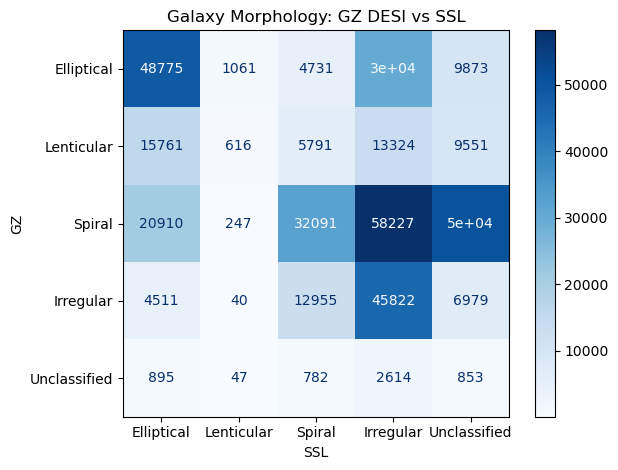

In [47]:
# Drop NaNs (just in case)
comparison_df = gz_with_sga_labels.dropna(subset=['Classification', 'morphology_pred']).copy()

# Make sure casing matches
comparison_df['Classification'] = comparison_df['Classification'].str.capitalize()
comparison_df['morphology_pred'] = comparison_df['morphology_pred'].str.capitalize()

# Define class labels in desired order
label_order = ['Elliptical', 'Lenticular', 'Spiral', 'Irregular', 'Unclassified']
#label_order = ['Elliptical', 'Spiral']

# Compute confusion matrix
cm = confusion_matrix(comparison_df['Classification'],
                      comparison_df['morphology_pred'],
                      labels=label_order)

# Display it nicely
disp = ConfusionMatrixDisplay(cm, display_labels=['Elliptical', 'Lenticular', 'Spiral', 'Irregular', 'Unclassified'])
disp.plot(cmap='Blues')
plt.title("Galaxy Morphology: GZ DESI vs SSL")
plt.xlabel("SSL")
plt.ylabel("GZ")
plt.tight_layout()
plt.show()

In [48]:
# Print classification report
print("\nClassification Report:")
print(classification_report(comparison_df['Classification'],
                            comparison_df['morphology_pred'],
                            labels=label_order,
                            digits=3))


Classification Report:
              precision    recall  f1-score   support

  Elliptical      0.537     0.515     0.526     94696
  Lenticular      0.306     0.014     0.026     45043
      Spiral      0.569     0.198     0.294    161900
   Irregular      0.305     0.652     0.416     70307
Unclassified      0.011     0.164     0.021      5191

    accuracy                          0.340    377137
   macro avg      0.346     0.309     0.256    377137
weighted avg      0.473     0.340     0.339    377137

